# Lab 10.15 - Recurrent Neural Networks
The aim of this lab is to build up your understanding of Recurrent Neural Networks and how they can be used to process sequence and time series data.

Work through chapter 15, pg 497 from the Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow (this is referring to 2nd edition) and complete the following:

## 1. Implement the simple RNN using the fabricated data from pg 504, then extend it to become a deep RNN, pg 508.

This builds the fabricated time series data from the book, trains a simple RNN, then extends it to a deep RNN.
### The Fabricated Dataset
The book generates a dataset of time series using sine waves with noise:

In [1]:
import tensorflow as tf
import numpy as np

tf.random.set_seed(13)
np.random.seed(13)

In [2]:
import numpy as np

def generate_time_series(batch_size, n_steps):
    freq1, freq2, offsets1, offsets2 = np.random.rand(4, batch_size, 1)
    time = np.linspace(0, 1, n_steps)
    series = 0.5 * np.sin((time - offsets1) * (freq1 * 10 + 10))   # wave 1
    series += 0.2 * np.sin((time - offsets2) * (freq2 * 20 + 20))  # wave 2
    series += 0.1 * (np.random.rand(batch_size, n_steps) - 0.5)    # noise
    return series[..., np.newaxis].astype(np.float32)

np.random.seed(13)   # unlucky for some
n_steps = 50
series = generate_time_series(10000, n_steps + 1)

# Split into train/val/test
X_train = series[:7000, :n_steps]
y_train = series[:7000, -1]
X_valid = series[7000:9000, :n_steps]
y_valid = series[7000:9000, -1]
X_test  = series[9000:, :n_steps]
y_test  = series[9000:, -1]

print("X_train shape:", X_train.shape)  # (7000, 50, 1)
print("y_train shape:", y_train.shape)  # (7000, 1)

X_train shape: (7000, 50, 1)
y_train shape: (7000, 1)


Each sample is 50 time steps, and the target is the 51st value — the next step.

### Simple RNN

In [3]:
model_simple = tf.keras.Sequential([
    tf.keras.layers.SimpleRNN(20, return_sequences=False, input_shape=[None, 1]),
    tf.keras.layers.Dense(1)
])

model_simple.compile(optimizer="adam", loss="mse", metrics=["mae"])
model_simple.summary()

history_simple = model_simple.fit(
    X_train, y_train,
    epochs=20,
    validation_data=(X_valid, y_valid),
    verbose=1
)

mse_simple = model_simple.evaluate(X_test, y_test, verbose=0)
print(f"\nSimple RNN — Test MSE: {mse_simple[0]:.4f}, MAE: {mse_simple[1]:.4f}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 20)             │           440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            21 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 461 (1.80 KB)

 Trainable params: 461 (1.80 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 0.0171 - mae: 0.0965 - val_loss: 0.0073 - val_mae: 0.0681
Epoch 2/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0059 - mae: 0.0611 - val_loss: 0.0051 - val_mae: 0.0574
Epoch 3/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0047 - mae: 0.0544 - val_loss: 0.0044 - val_mae: 0.0532
Epoch 4/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0042 - mae: 0.0513 - val_loss: 0.0040 - val_mae: 0.0508
Epoch 5/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0039 - mae: 0.0495 - val_loss: 0.0037 - val_mae: 0.0490
Epoch 6/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0037 - mae: 0.0484 - val_loss: 0.0035 - val_mae: 0.0481
Epoch 7/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0036 - mae: 0.0479 - val_loss: 0.0035 - val_mae: 0.0478
Epoch 8/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0036 - mae: 0.0477 - val_loss: 0.0035 - val_mae: 0.0476
Epoch 9/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - l

### Deep RNN
To make it deep, you stack multiple `SimpleRNN` layers. All layers except the last need `return_sequences=True` so they pass their full output sequence to the next layer:

In [4]:
model_deep = tf.keras.Sequential([
    tf.keras.layers.SimpleRNN(20, return_sequences=True, input_shape=[None, 1]),
    tf.keras.layers.SimpleRNN(20, return_sequences=True),
    tf.keras.layers.SimpleRNN(20),   # last RNN layer — only final step needed
    tf.keras.layers.Dense(1)
])

model_deep.compile(optimizer="adam", loss="mse", metrics=["mae"])
model_deep.summary()

history_deep = model_deep.fit(
    X_train, y_train,
    epochs=20,
    validation_data=(X_valid, y_valid),
    verbose=1
)

mse_deep = model_deep.evaluate(X_test, y_test, verbose=0)
print(f"\nDeep RNN    — Test MSE: {mse_deep[0]:.4f}, MAE: {mse_deep[1]:.4f}")

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_1 (SimpleRNN)        │ (None, None, 20)       │           440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_2 (SimpleRNN)        │ (None, None, 20)       │           820 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_3 (SimpleRNN)        │ (None, 20)             │           820 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            21 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,101 (8.21 KB)

 Trainable params: 2,101 (8.21 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 9s 25ms/step - loss: 0.0373 - mae: 0.1290 - val_loss: 0.0100 - val_mae: 0.0804
Epoch 2/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.0070 - mae: 0.0669 - val_loss: 0.0052 - val_mae: 0.0571
Epoch 3/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.0051 - mae: 0.0572 - val_loss: 0.0042 - val_mae: 0.0513
Epoch 4/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0044 - mae: 0.0533 - val_loss: 0.0037 - val_mae: 0.0483
Epoch 5/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0040 - mae: 0.0507 - val_loss: 0.0034 - val_mae: 0.0467
Epoch 6/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0037 - mae: 0.0490 - val_loss: 0.0033 - val_mae: 0.0462
Epoch 7/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0036 - mae: 0.0478 - val_loss: 0.0033 - val_mae: 0.0459
Epoch 8/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 0.0034 - mae: 0.0471 - val_loss: 0.0033 - val_mae: 0.0456
Epoch 9/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/

Key concepts here:

`return_sequences=True` Passes the full sequence of hidden states to the next layer (required for stacking)

`return_sequences=False` Only the final time step's hidden state is passed forward (used at the last RNN layer)

`input_shape=[None, 1]` None means "any number of time steps", 1 is the number of features per step

`Dense(1)` Produces a single scalar prediction (next time step value)



## 2. The current model lets you predict the next step, now update your model to forecast several time steps ahead (pg 508-509).

The key shift here is: instead of predicting one next value, we want to predict multiple future values. The book covers two approaches — we'll implement both.


---


### The New Target Data
First, we need to reshape our targets. Instead of y being the single next value, it becomes a window of the next 10 values:

In [5]:
# Same data generation as before
def generate_time_series(batch_size, n_steps):
    freq1, freq2, offsets1, offsets2 = np.random.rand(4, batch_size, 1)
    time = np.linspace(0, 1, n_steps)
    series = 0.5 * np.sin((time - offsets1) * (freq1 * 10 + 10))
    series += 0.2 * np.sin((time - offsets2) * (freq2 * 20 + 20))
    series += 0.1 * (np.random.rand(batch_size, n_steps) - 0.5)
    return series[..., np.newaxis].astype(np.float32)

n_steps = 50
n_steps_ahead = 10  # how many future steps we want to predict

# We now need 50 input steps + 10 future steps = 60 total
series = generate_time_series(10000, n_steps + n_steps_ahead)

X_train = series[:7000, :n_steps]           # input: steps 0–49
y_train = series[:7000, n_steps:]           # target: steps 50–59  → shape (7000, 10, 1)
X_valid = series[7000:9000, :n_steps]
y_valid = series[7000:9000, n_steps:]
X_test  = series[9000:, :n_steps]
y_test  = series[9000:, n_steps:]

# Squeeze out the trailing feature dimension for the targets
y_train = y_train.squeeze(-1)  # (7000, 10)
y_valid = y_valid.squeeze(-1)
y_test  = y_test.squeeze(-1)

print("X_train shape:", X_train.shape)  # (7000, 50, 1)
print("y_train shape:", y_train.shape)  # (7000, 10)

X_train shape: (7000, 50, 1)
y_train shape: (7000, 10)


### Approach 1: Sequence-to-Vector (Single Shot)
The simplest idea: read in the whole sequence, then output all 10 predictions at once from a single Dense layer at the end. The RNN summarises the entire input into a context vector, and the Dense layer maps that to 10 values.

In [6]:
model_seq2vec = tf.keras.Sequential([
    tf.keras.layers.SimpleRNN(20, return_sequences=True, input_shape=[None, 1]),
    tf.keras.layers.SimpleRNN(20),       # final step only — context vector
    tf.keras.layers.Dense(n_steps_ahead) # output all 10 predictions at once
])

model_seq2vec.compile(optimizer="adam", loss="mse", metrics=["mae"])
model_seq2vec.summary()

history_s2v = model_seq2vec.fit(
    X_train, y_train,
    epochs=20,
    validation_data=(X_valid, y_valid),
    verbose=1
)

mse_s2v = model_seq2vec.evaluate(X_test, y_test, verbose=0)
print(f"\nSeq-to-Vec — Test MSE: {mse_s2v[0]:.4f}, MAE: {mse_s2v[1]:.4f}")

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_4 (SimpleRNN)        │ (None, None, 20)       │           440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_5 (SimpleRNN)        │ (None, 20)             │           820 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           210 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,470 (5.74 KB)

 Trainable params: 1,470 (5.74 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step - loss: 0.0553 - mae: 0.1789 - val_loss: 0.0312 - val_mae: 0.1376
Epoch 2/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0244 - mae: 0.1210 - val_loss: 0.0185 - val_mae: 0.1060
Epoch 3/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0157 - mae: 0.0974 - val_loss: 0.0141 - val_mae: 0.0924
Epoch 4/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0134 - mae: 0.0899 - val_loss: 0.0137 - val_mae: 0.0905
Epoch 5/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0124 - mae: 0.0863 - val_loss: 0.0129 - val_mae: 0.0879
Epoch 6/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0118 - mae: 0.0840 - val_loss: 0.0132 - val_mae: 0.0885
Epoch 7/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0113 - mae: 0.0821 - val_loss: 0.0122 - val_mae: 0.0852
Epoch 8/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0109 - mae: 0.0810 - val_loss: 0.0109 - val_mae: 0.0810
Epoch 9/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step -

**The intuition:** The RNN reads all 50 steps and squashes everything it learned into a single summary. The Dense layer then uses that summary to guess all 10 future values simultaneously. Simple, but the further ahead you predict, the less confident those later guesses will be.

### Approach 2: Sequence-to-Sequence (Step by Step)
A smarter approach: instead of only predicting at the end, we make the RNN output a prediction at every single time step. At step t, it uses everything it's seen so far (steps 0 to t) to predict the next 10 values from that point.
This means the model gets 50 training signals per sequence instead of 1, which makes training much richer.

In [7]:
# We need targets aligned at every time step:
# At step t, the target is the next 10 values from position t onwards
series = generate_time_series(10000, n_steps + n_steps_ahead)

# Build per-step targets: shape (samples, n_steps, n_steps_ahead)
# At each of the 50 input steps, we want the next 10 values as the target
Y = np.empty((10000, n_steps, n_steps_ahead))
for step_ahead in range(1, n_steps_ahead + 1):
    Y[:, :, step_ahead - 1] = series[:, step_ahead:step_ahead + n_steps, 0]

X_train_s2s = series[:7000, :n_steps]
Y_train_s2s = Y[:7000]
X_valid_s2s = series[7000:9000, :n_steps]
Y_valid_s2s = Y[7000:9000]
X_test_s2s  = series[9000:, :n_steps]
Y_test_s2s  = Y[9000:]

print("X_train shape:", X_train_s2s.shape)   # (7000, 50, 1)
print("Y_train shape:", Y_train_s2s.shape)   # (7000, 50, 10)

X_train shape: (7000, 50, 1)
Y_train shape: (7000, 50, 10)


Now the model outputs 10 predictions at every time step, using a TimeDistributed Dense layer — which just means "apply this same Dense layer independently at each time step":

In [8]:
model_seq2seq = tf.keras.Sequential([
    tf.keras.layers.SimpleRNN(20, return_sequences=True, input_shape=[None, 1]),
    tf.keras.layers.SimpleRNN(20, return_sequences=True),  # keep ALL steps this time
    tf.keras.layers.TimeDistributed(tf.keras.layers.Dense(n_steps_ahead))
    # equivalent shorthand: tf.keras.layers.Dense(n_steps_ahead)
    # Keras applies Dense across time automatically when input is 3D
])

model_seq2seq.compile(optimizer="adam", loss="mse", metrics=["mae"])
model_seq2seq.summary()

history_s2s = model_seq2seq.fit(
    X_train_s2s, Y_train_s2s,
    epochs=20,
    validation_data=(X_valid_s2s, Y_valid_s2s),
    verbose=1
)

# At inference, we only care about the predictions made at the LAST time step
Y_pred = model_seq2seq.predict(X_test_s2s)
last_step_pred = Y_pred[:, -1, :]   # shape: (1000, 10) — the final forecast

mse_s2s = np.mean(tf.keras.losses.mse(Y_test_s2s[:, -1, :], last_step_pred))
print(f"\nSeq-to-Seq — Test MSE (last step): {mse_s2s:.4f}")

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_6 (SimpleRNN)        │ (None, None, 20)       │           440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_7 (SimpleRNN)        │ (None, None, 20)       │           820 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, None, 10)       │           210 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,470 (5.74 KB)

 Trainable params: 1,470 (5.74 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 17s 41ms/step - loss: 0.0680 - mae: 0.2013 - val_loss: 0.0468 - val_mae: 0.1665
Epoch 2/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0424 - mae: 0.1566 - val_loss: 0.0396 - val_mae: 0.1492
Epoch 3/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0385 - mae: 0.1469 - val_loss: 0.0373 - val_mae: 0.1435
Epoch 4/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0367 - mae: 0.1424 - val_loss: 0.0358 - val_mae: 0.1399
Epoch 5/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0355 - mae: 0.1397 - val_loss: 0.0347 - val_mae: 0.1375
Epoch 6/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0342 - mae: 0.1367 - val_loss: 0.0335 - val_mae: 0.1348
Epoch 7/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0330 - mae: 0.1341 - val_loss: 0.0325 - val_mae: 0.1327
Epoch 8/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0321 - mae: 0.1319 - val_loss: 0.0318 - val_mae: 0.1308
Epoch 9/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step

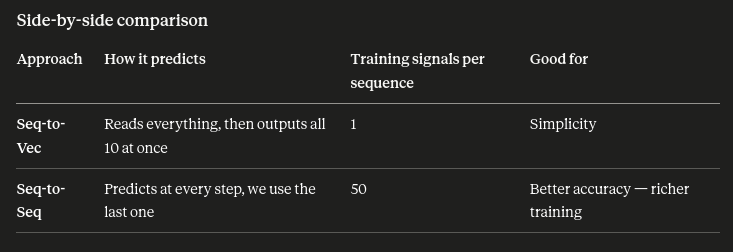

The seq-to-seq model typically wins because the model is constantly practising forecasting throughout the whole sequence, not just at the very end. Think of it like the difference between a student who only gets feedback at the end of an exam vs one who gets feedback after every question.

## 3. Next improve your model by including layer normalisation.

Layer Normalisation helps stabilise training by normalising the outputs within each layer. In RNNs specifically it helps with the vanishing/exploding gradient problem that makes deep networks hard to train.

The clean way to add it is with a custom RNN cell that wraps a `SimpleRNNCell` and applies `LayerNormalization` after each step.

### Custom Layer-Normalised RNN Cell

In [13]:
class LNSimpleRNNCell(tf.keras.layers.Layer):
    def __init__(self, units, **kwargs):
        super().__init__(**kwargs)
        self.units = units
        self.simple_rnn_cell = tf.keras.layers.SimpleRNNCell(units)
        self.layer_norm = tf.keras.layers.LayerNormalization()

    @property
    def state_size(self):
        return self.units

    def get_initial_state(self, batch_size=None, dtype=None):
        if dtype is None:
            dtype = tf.float32  # fallback if Keras doesn't pass a dtype
        return [tf.zeros([batch_size, self.units], dtype=dtype)]

    def call(self, inputs, states):
        outputs, new_states = self.simple_rnn_cell(inputs, states)
        normed = self.layer_norm(outputs)
        return normed, [normed]

**The intuition:** At every time step, after the RNN cell does its calculation, we normalise the output so its values have a consistent scale. This stops any one time step from producing wildly large or small values that would destabilise training.

### Building the Model
We plug our custom cell into a standard RNN layer, then stack it like before:

In [14]:
model_ln = tf.keras.Sequential([
    tf.keras.layers.RNN(LNSimpleRNNCell(20), return_sequences=True, input_shape=[None, 1]),
    tf.keras.layers.RNN(LNSimpleRNNCell(20), return_sequences=True),
    tf.keras.layers.TimeDistributed(tf.keras.layers.Dense(n_steps_ahead))
])

model_ln.compile(optimizer="adam", loss="mse", metrics=["mae"])
model_ln.summary()

history_ln = model_ln.fit(
    X_train_s2s, Y_train_s2s,
    epochs=20,
    validation_data=(X_valid_s2s, Y_valid_s2s),
    verbose=1
)

Y_pred_ln = model_ln.predict(X_test_s2s)
mse_ln = np.mean(tf.keras.losses.mse(Y_test_s2s[:, -1, :], Y_pred_ln[:, -1, :]))
print(f"\nLayer Norm RNN — Test MSE (last step): {mse_ln:.4f}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:424: UserWarning: `build()` was called on layer 'ln_simple_rnn_cell_6', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:424: UserWarning: `build()` was called on layer 'ln_simple_rnn_cell_7', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rnn_6 (RNN)                     │ (None, None, 20)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rnn_7 (RNN)                     │ (None, None, 20)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_4              │ (None, None, 10)       │           210 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 210 (840.00 B)

 Trainable params: 210 (840.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 20s 48ms/step - loss: 0.2438 - mae: 0.3765 - val_loss: 0.1070 - val_mae: 0.2660
Epoch 2/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.0820 - mae: 0.2254 - val_loss: 0.0663 - val_mae: 0.1997
Epoch 3/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0611 - mae: 0.1920 - val_loss: 0.0641 - val_mae: 0.1952
Epoch 4/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0580 - mae: 0.1857 - val_loss: 0.0544 - val_mae: 0.1801
Epoch 5/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0527 - mae: 0.1773 - val_loss: 0.0494 - val_mae: 0.1710
Epoch 6/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0481 - mae: 0.1685 - val_loss: 0.0472 - val_mae: 0.1661
Epoch 7/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0456 - mae: 0.1633 - val_loss: 0.0447 - val_mae: 0.1608
Epoch 8/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0432 - mae: 0.1583 - val_loss: 0.0421 - val_mae: 0.1552
Epoch 9/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms

### Why Layer Norm rather than Batch Norm?
You might have used Batch Normalisation in feedforward networks before. For RNNs, it's a poor fit because it normalises across the batch, meaning the statistics it computes change depending on what other sequences happen to be in the same batch — noisy and inconsistent for sequence data.
Layer Normalisation normalises across the features within a single time step, so each step is treated independently and consistently regardless of what else is in the batch. Much better behaved for sequences.

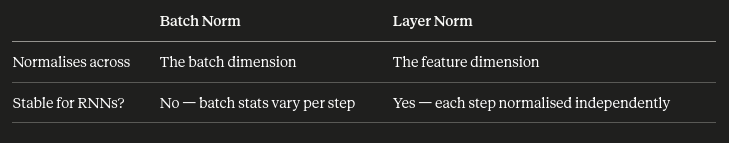

## 4. Change your network to use the LSTM cell? What if you swap in the GRU cell, instead? Does it perform any better?

The good news here is that after all the custom cell work in Q3, this is much simpler — Keras has LSTM and GRU built in, so it's mostly just swapping layer names.



---

### Why LSTM and GRU?
`SimpleRNN` struggles with long-range dependencies — information from early time steps gets diluted as it passes through many steps, which is the vanishing gradient problem. LSTM and GRU both solve this with gating mechanisms that learn what to remember and what to forget.

*   LSTM has three gates (input, forget, output) and a separate cell state that acts as a long-term memory conveyor belt alongside the hidden state
*   GRU is a streamlined version with two gates — fewer parameters, faster to train, and often performs just as well



### LSTM Model

In [15]:
model_lstm = tf.keras.Sequential([
    tf.keras.layers.LSTM(20, return_sequences=True, input_shape=[None, 1]),
    tf.keras.layers.LSTM(20, return_sequences=True),
    tf.keras.layers.TimeDistributed(tf.keras.layers.Dense(n_steps_ahead))
])

model_lstm.compile(optimizer="adam", loss="mse", metrics=["mae"])
model_lstm.summary()

history_lstm = model_lstm.fit(
    X_train_s2s, Y_train_s2s,
    epochs=20,
    validation_data=(X_valid_s2s, Y_valid_s2s),
    verbose=1
)

Y_pred_lstm = model_lstm.predict(X_test_s2s)
mse_lstm = np.mean(tf.keras.losses.mse(Y_test_s2s[:, -1, :], Y_pred_lstm[:, -1, :]))
print(f"\nLSTM — Test MSE (last step): {mse_lstm:.4f}")

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, None, 20)       │         1,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, None, 20)       │         3,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_5              │ (None, None, 10)       │           210 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,250 (20.51 KB)

 Trainable params: 5,250 (20.51 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 9s 16ms/step - loss: 0.0778 - mae: 0.2249 - val_loss: 0.0548 - val_mae: 0.1849
Epoch 2/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.0477 - mae: 0.1694 - val_loss: 0.0420 - val_mae: 0.1560
Epoch 3/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.0379 - mae: 0.1459 - val_loss: 0.0355 - val_mae: 0.1395
Epoch 4/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 0.0339 - mae: 0.1359 - val_loss: 0.0332 - val_mae: 0.1336
Epoch 5/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0319 - mae: 0.1307 - val_loss: 0.0314 - val_mae: 0.1292
Epoch 6/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.0304 - mae: 0.1269 - val_loss: 0.0301 - val_mae: 0.1257
Epoch 7/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 0.0293 - mae: 0.1241 - val_loss: 0.0292 - val_mae: 0.1236
Epoch 8/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.0284 - mae: 0.1217 - val_loss: 0.0285 - val_mae: 0.1218
Epoch 9/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/

### GRU Model

In [16]:
model_gru = tf.keras.Sequential([
    tf.keras.layers.GRU(20, return_sequences=True, input_shape=[None, 1]),
    tf.keras.layers.GRU(20, return_sequences=True),
    tf.keras.layers.TimeDistributed(tf.keras.layers.Dense(n_steps_ahead))
])

model_gru.compile(optimizer="adam", loss="mse", metrics=["mae"])
model_gru.summary()

history_gru = model_gru.fit(
    X_train_s2s, Y_train_s2s,
    epochs=20,
    validation_data=(X_valid_s2s, Y_valid_s2s),
    verbose=1
)

Y_pred_gru = model_gru.predict(X_test_s2s)
mse_gru = np.mean(tf.keras.losses.mse(Y_test_s2s[:, -1, :], Y_pred_gru[:, -1, :]))
print(f"\nGRU  — Test MSE (last step): {mse_gru:.4f}")

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, None, 20)       │         1,380 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, None, 20)       │         2,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_6              │ (None, None, 10)       │           210 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,110 (16.05 KB)

 Trainable params: 4,110 (16.05 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - loss: 0.0741 - mae: 0.2195 - val_loss: 0.0549 - val_mae: 0.1847
Epoch 2/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.0489 - mae: 0.1706 - val_loss: 0.0452 - val_mae: 0.1612
Epoch 3/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.0423 - mae: 0.1551 - val_loss: 0.0401 - val_mae: 0.1499
Epoch 4/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 0.0369 - mae: 0.1432 - val_loss: 0.0344 - val_mae: 0.1372
Epoch 5/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.0328 - mae: 0.1339 - val_loss: 0.0321 - val_mae: 0.1319
Epoch 6/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.0312 - mae: 0.1303 - val_loss: 0.0311 - val_mae: 0.1296
Epoch 7/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 0.0300 - mae: 0.1275 - val_loss: 0.0299 - val_mae: 0.1268
Epoch 8/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 0.0290 - mae: 0.1251 - val_loss: 0.0290 - val_mae: 0.1245
Epoch 9/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/

### Summary comparison across all models so far

In [17]:
print("=" * 40)
print(f"Simple RNN (Q1)     MSE: {mse_simple[0]:.4f}")
print(f"Deep RNN   (Q1)     MSE: {mse_deep[0]:.4f}")
print(f"Seq-to-Vec (Q2)     MSE: {mse_s2v[0]:.4f}")
print(f"Seq-to-Seq (Q2)     MSE: {mse_s2s:.4f}")
print(f"Layer Norm (Q3)     MSE: {mse_ln:.4f}")
print(f"LSTM       (Q4)     MSE: {mse_lstm:.4f}")
print(f"GRU        (Q4)     MSE: {mse_gru:.4f}")
print("=" * 40)

Simple RNN (Q1)     MSE: 0.0034
Deep RNN   (Q1)     MSE: 0.0032
Seq-to-Vec (Q2)     MSE: 0.0089
Seq-to-Seq (Q2)     MSE: 0.0129
Layer Norm (Q3)     MSE: 0.0329
LSTM       (Q4)     MSE: 0.0084
GRU        (Q4)     MSE: 0.0110


###What to expect
On this particular dataset the differences are often small — the fabricated sine wave data isn't complex enough to truly stress-test long-range memory. But as a rule of thumb:

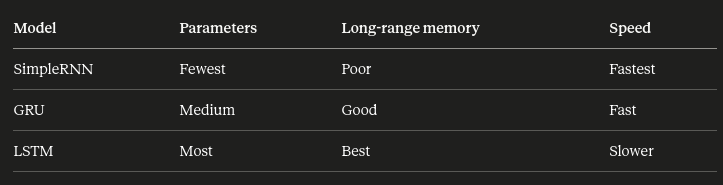

GRU often matches LSTM on simpler tasks while being quicker to train, which is why it's a popular default choice before reaching for the heavier LSTM.

## 5. Now create the model with the suggested 1D convolutional layer. How much of a difference does the convolutional make when applied to a network with LSTM cells and GRU cells, respectively.

**Why add a Conv1D?**
Before the RNN even sees the data, a 1D convolutional layer acts as a pattern detector across short windows of the sequence. Think of it like a sliding magnifying glass — it scans across the time series picking up local patterns (short bumps, trends, repeating shapes), then hands a compressed, feature-rich version of the sequence to the RNN.

The RNN then only needs to focus on longer-range dependencies across these extracted features, rather than doing all the work itself. This often speeds up training and improves accuracy.

###Conv1D + LSTM

In [20]:
model_conv_lstm = tf.keras.Sequential([
    # Conv1D scans with a window of 4 time steps, producing 20 feature maps
    tf.keras.layers.Conv1D(filters=20, kernel_size=4, strides=1,
                           padding="same", activation="relu",
                           input_shape=[None, 1]),
    tf.keras.layers.LSTM(20, return_sequences=True),
    tf.keras.layers.LSTM(20, return_sequences=True),
    tf.keras.layers.TimeDistributed(tf.keras.layers.Dense(n_steps_ahead))
])

model_conv_lstm.compile(optimizer="adam", loss="mse", metrics=["mae"])
model_conv_lstm.summary()

history_conv_lstm = model_conv_lstm.fit(
    X_train_s2s, Y_train_s2s,
    epochs=20,
    validation_data=(X_valid_s2s, Y_valid_s2s),
    verbose=1
)

Y_pred_conv_lstm = model_conv_lstm.predict(X_test_s2s)
mse_conv_lstm = np.mean(tf.keras.losses.mse(Y_test_s2s[:, -1, :], Y_pred_conv_lstm[:, -1, :]))
print(f"\nConv1D + LSTM — Test MSE (last step): {mse_conv_lstm:.4f}")

Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_2 (Conv1D)               │ (None, None, 20)       │           100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, None, 20)       │         3,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, None, 20)       │         3,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_9              │ (None, None, 10)       │           210 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,870 (26.84 KB)

 Trainable params: 6,870 (26.84 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - loss: 0.0653 - mae: 0.1996 - val_loss: 0.0380 - val_mae: 0.1456
Epoch 2/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0325 - mae: 0.1332 - val_loss: 0.0291 - val_mae: 0.1246
Epoch 3/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0261 - mae: 0.1164 - val_loss: 0.0246 - val_mae: 0.1117
Epoch 4/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - loss: 0.0233 - mae: 0.1082 - val_loss: 0.0227 - val_mae: 0.1063
Epoch 5/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0219 - mae: 0.1041 - val_loss: 0.0215 - val_mae: 0.1031
Epoch 6/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0209 - mae: 0.1014 - val_loss: 0.0207 - val_mae: 0.1006
Epoch 7/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0200 - mae: 0.0991 - val_loss: 0.0200 - val_mae: 0.0987
Epoch 8/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.0192 - mae: 0.0969 - val_loss: 0.0192 - val_mae: 0.0966
Epoch 9/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/

### Conv1D + GRU

In [21]:
model_conv_gru = tf.keras.Sequential([
    tf.keras.layers.Conv1D(filters=20, kernel_size=4, strides=1,
                           padding="same", activation="relu",
                           input_shape=[None, 1]),
    tf.keras.layers.GRU(20, return_sequences=True),
    tf.keras.layers.GRU(20, return_sequences=True),
    tf.keras.layers.TimeDistributed(tf.keras.layers.Dense(n_steps_ahead))
])

model_conv_gru.compile(optimizer="adam", loss="mse", metrics=["mae"])
model_conv_gru.summary()

history_conv_gru = model_conv_gru.fit(
    X_train_s2s, Y_train_s2s,
    epochs=20,
    validation_data=(X_valid_s2s, Y_valid_s2s),
    verbose=1
)

Y_pred_conv_gru = model_conv_gru.predict(X_test_s2s)
mse_conv_gru = np.mean(tf.keras.losses.mse(Y_test_s2s[:, -1, :], Y_pred_conv_gru[:, -1, :]))
print(f"\nConv1D + GRU  — Test MSE (last step): {mse_conv_gru:.4f}")

Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_3 (Conv1D)               │ (None, None, 20)       │           100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_4 (GRU)                     │ (None, None, 20)       │         2,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_5 (GRU)                     │ (None, None, 20)       │         2,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_10             │ (None, None, 10)       │           210 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,350 (20.90 KB)

 Trainable params: 5,350 (20.90 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - loss: 0.0614 - mae: 0.1906 - val_loss: 0.0398 - val_mae: 0.1456
Epoch 2/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.0362 - mae: 0.1365 - val_loss: 0.0342 - val_mae: 0.1304
Epoch 3/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.0320 - mae: 0.1261 - val_loss: 0.0302 - val_mae: 0.1222
Epoch 4/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.0287 - mae: 0.1198 - val_loss: 0.0277 - val_mae: 0.1174
Epoch 5/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 0.0264 - mae: 0.1151 - val_loss: 0.0258 - val_mae: 0.1135
Epoch 6/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.0241 - mae: 0.1103 - val_loss: 0.0232 - val_mae: 0.1078
Epoch 7/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0219 - mae: 0.1049 - val_loss: 0.0215 - val_mae: 0.1032
Epoch 8/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.0207 - mae: 0.1015 - val_loss: 0.0206 - val_mae: 0.1007
Epoch 9/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/

### What the Conv1D parameters mean
`tf.keras.layers.Conv1D(filters=20, kernel_size=4, strides=1, padding="same")`

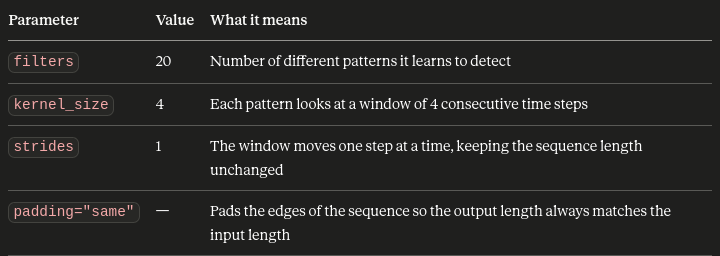

The `strides=2` is worth noting — it means the RNN receives a sequence half the original length, but each step is now a richer, pre-processed feature rather than a raw value. The RNN does less work but on better inputs.

### Full comparison

In [22]:
print("=" * 45)
print(f"Simple RNN       (Q1)  MSE: {mse_simple[0]:.4f}")
print(f"Deep RNN         (Q1)  MSE: {mse_deep[0]:.4f}")
print(f"Seq-to-Vec       (Q2)  MSE: {mse_s2v[0]:.4f}")
print(f"Seq-to-Seq       (Q2)  MSE: {mse_s2s:.4f}")
print(f"Layer Norm RNN   (Q3)  MSE: {mse_ln:.4f}")
print(f"LSTM             (Q4)  MSE: {mse_lstm:.4f}")
print(f"GRU              (Q4)  MSE: {mse_gru:.4f}")
print(f"Conv1D + LSTM    (Q5)  MSE: {mse_conv_lstm:.4f}")
print(f"Conv1D + GRU     (Q5)  MSE: {mse_conv_gru:.4f}")
print("=" * 45)

Simple RNN       (Q1)  MSE: 0.0034
Deep RNN         (Q1)  MSE: 0.0032
Seq-to-Vec       (Q2)  MSE: 0.0089
Seq-to-Seq       (Q2)  MSE: 0.0129
Layer Norm RNN   (Q3)  MSE: 0.0329
LSTM             (Q4)  MSE: 0.0084
GRU              (Q4)  MSE: 0.0110
Conv1D + LSTM    (Q5)  MSE: 0.0182
Conv1D + GRU     (Q5)  MSE: 0.0230


### What to expect
The convolutional layer typically gives a modest but consistent improvement, especially for the GRU which benefits most from having local features pre-extracted. The pattern usually looks something like:

Conv + LSTM ≈ similar to plain LSTM or slightly better
Conv + GRU ≈ often closes the gap with LSTM, sometimes beats it

The real benefit of Conv1D shows more on longer, noisier real-world sequences where local feature extraction makes a bigger difference than on our clean fabricated sine waves.

## 6. Work through Chapter 16, as this is specifically about using RNNs for Natural Language Processing (pg 525-540)

This question is just a bit open ended and a bit lazy. So I've decided to just make up my own excercise using IMDB for sentiment analysis.

### Sentiment Analysis with RNNs (Chapter 16)
The task is to classify IMDB movie reviews as positive or negative. This is a natural extension of everything we've built — instead of a time series of numbers, our sequence is now a series of words.

### New concepts this introduces
Before the code, two key ideas that are new here:

**Tokenisation** — text can't be fed into a neural network raw. Each unique word gets mapped to an integer ID. So `"the film was great"` might become `[2, 45, 13, 678]`.

**Embeddings** — rather than using those raw integers, we learn a dense vector of floats for each word. Words with similar meanings end up with similar vectors. This is much richer than one-hot encoding and is the standard way to feed text into RNNs.

### Load and prepare the data

### Alternative Data Loading: Using `tf.keras.datasets.imdb`

When `tensorflow_datasets` encounters issues, `tf.keras.datasets.imdb.load_data()` provides a robust alternative for accessing the IMDB dataset. This function directly returns pre-tokenized sequences (as integers) and their labels, simplifying the initial data preparation steps. We will then pad these sequences to a uniform length and split them into training, validation, and test sets, just as you intended with `tfds`.

In [25]:
import tensorflow as tf
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Define parameters (as used in the original cell)
vocab_size = 1000  # only keep the 1000 most common words
max_length = 600   # truncate/pad all reviews to this length
BUFFER_SIZE = tf.data.AUTOTUNE # For efficient data pipeline
BATCH_SIZE = 32

# Load IMDB reviews dataset using tf.keras.datasets
# num_words: limits the vocabulary to the most frequent words
# oov_mode=2: index for out-of-vocabulary words (can be 1 or 2)
(x_train_full, y_train_full), (x_test, y_test) = tf.keras.datasets.imdb.load_data(
    num_words=vocab_size,
    oov_mode=2
)

# Pad sequences to max_length for consistent input size
x_train_padded = pad_sequences(x_train_full, maxlen=max_length, padding='post', truncating='post')
x_test_padded = pad_sequences(x_test, maxlen=max_length, padding='post', truncating='post')

# Manually split training data into training and validation sets (90% train, 10% valid)
# This mimics the original tfds.load split ["train[:90%]", "train[90%:]"]
train_size = int(len(x_train_padded) * 0.9)
x_train, x_valid = x_train_padded[:train_size], x_train_padded[train_size:]
y_train, y_valid = y_train_full[:train_size], y_train_full[train_size:]

# Create tf.data.Dataset objects for efficient processing (batching and prefetching)
train_set = tf.data.Dataset.from_tensor_slices((x_train, y_train))
valid_set = tf.data.Dataset.from_tensor_slices((x_valid, y_valid))
test_set = tf.data.Dataset.from_tensor_slices((x_test_padded, y_test))

train_set = train_set.batch(BATCH_SIZE).prefetch(BUFFER_SIZE)
valid_set = valid_set.batch(BATCH_SIZE).prefetch(BUFFER_SIZE)
test_set = test_set.batch(BATCH_SIZE).prefetch(BUFFER_SIZE)

print("Data ready using tf.keras.datasets.imdb.load_data().")
print(f"Vocabulary size: {vocab_size}")
print(f"Max review length: {max_length} tokens")

# Optional: Display a sample of the processed data
for x_batch, y_batch in train_set.take(1):
    print("\nSample processed batch shape (features, labels):")
    print(x_batch.shape, y_batch.shape)
    print("Sample feature sequence (first review in batch):\n", x_batch[0].numpy()[:20]) # Show first 20 tokens
    print("Sample label (first review in batch): ", y_batch[0].numpy())

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Data ready using tf.keras.datasets.imdb.load_data().
Vocabulary size: 1000
Max review length: 600 tokens

Sample processed batch shape (features, labels):
(32, 600) (32,)
Sample feature sequence (first review in batch):
 [  1  14  22  16  43 530 973   2   2  65 458   2  66   2   4 173  36 256
   5  25]
Sample label (first review in batch):  1


### Model 1: Simple LSTM Sentiment CLassifier

In [26]:
embed_size = 128  # each word gets represented as a 128-dimensional vector

model_sentiment = tf.keras.Sequential([
    # Embedding layer: turns integer word IDs into dense vectors
    # vocab_size+1 because index 0 is reserved for padding
    tf.keras.layers.Embedding(input_dim=vocab_size + 1,
                              output_dim=embed_size,
                              mask_zero=True),  # ignore padding tokens
    tf.keras.layers.LSTM(32, return_sequences=True),
    tf.keras.layers.LSTM(32),
    tf.keras.layers.Dense(1, activation="sigmoid")  # sigmoid for binary classification
])

model_sentiment.compile(optimizer="adam",
                         loss="binary_crossentropy",  # binary because positive/negative
                         metrics=["accuracy"])
model_sentiment.summary()

history_sentiment = model_sentiment.fit(
    train_set,
    epochs=10,
    validation_data=valid_set
)

test_loss, test_acc = model_sentiment.evaluate(test_set)
print(f"\nSentiment LSTM — Test Accuracy: {test_acc:.4f}")

Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_6 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 38s 48ms/step - accuracy: 0.7630 - loss: 0.4890 - val_accuracy: 0.8172 - val_loss: 0.4028
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 36s 43ms/step - accuracy: 0.8241 - loss: 0.4028 - val_accuracy: 0.7904 - val_loss: 0.4666
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 30s 42ms/step - accuracy: 0.8343 - loss: 0.3751 - val_accuracy: 0.8364 - val_loss: 0.3807
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 27s 39ms/step - accuracy: 0.8514 - loss: 0.3483 - val_accuracy: 0.8524 - val_loss: 0.3585
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 27s 39ms/step - accuracy: 0.8348 - loss: 0.3725 - val_accuracy: 0.7768 - val_loss: 0.5051
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 27s 39ms/step - accuracy: 0.8351 - loss: 0.3807 - val_accuracy: 0.8416 - val_loss: 0.3967
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 27s 38ms/step - accuracy: 0.8675 - loss: 0.3172 - val_accuracy: 0.8640 - val_loss: 0.3462
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 41s 39ms/step - accuracy: 0.8856 - loss: 0.2803 - 

**A few things worth noting here:**

- `mask_zero=True` tells the model to ignore padding tokens — reviews shorter than 600 words get padded with zeros, and we don't want the RNN wasting effort processing those

- We switch to `sigmoid` + `binary_crossentropy` instead of MSE because this is now a classification problem, not regression

- The output is a single value between 0 and 1 — above 0.5 means positive, below means negative

### Model 2: Adding a GRU for comparison

In [27]:
model_sentiment_gru = tf.keras.Sequential([
    tf.keras.layers.Embedding(input_dim=vocab_size + 1,
                              output_dim=embed_size,
                              mask_zero=True),
    tf.keras.layers.GRU(32, return_sequences=True),
    tf.keras.layers.GRU(32),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

model_sentiment_gru.compile(optimizer="adam",
                              loss="binary_crossentropy",
                              metrics=["accuracy"])

history_sentiment_gru = model_sentiment_gru.fit(
    train_set,
    epochs=10,
    validation_data=valid_set
)

test_loss_gru, test_acc_gru = model_sentiment_gru.evaluate(test_set)
print(f"\nSentiment GRU  — Test Accuracy: {test_acc_gru:.4f}")

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 31s 41ms/step - accuracy: 0.7320 - loss: 0.5288 - val_accuracy: 0.7516 - val_loss: 0.5031
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 27s 38ms/step - accuracy: 0.8434 - loss: 0.3654 - val_accuracy: 0.8612 - val_loss: 0.3427
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 27s 38ms/step - accuracy: 0.8752 - loss: 0.3008 - val_accuracy: 0.8564 - val_loss: 0.3538
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 27s 38ms/step - accuracy: 0.8917 - loss: 0.2691 - val_accuracy: 0.8644 - val_loss: 0.3440
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 27s 38ms/step - accuracy: 0.9007 - loss: 0.2492 - val_accuracy: 0.8748 - val_loss: 0.3197
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 28s 40ms/step - accuracy: 0.9098 - loss: 0.2290 - val_accuracy: 0.8664 - val_loss: 0.3427
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 27s 38ms/step - accuracy: 0.9218 - loss: 0.2092 - val_accuracy: 0.8616 - val_loss: 0.3760
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 27s 39ms/step - accuracy: 0.9295 - loss: 0.1912 - 

### Try from your own review

In [29]:
def predict_sentiment(reviews):
    # Get the word index dictionary that maps words to their integer IDs
    word_index = tf.keras.datasets.imdb.get_word_index()

    def encode_review(text):
        # Clean and tokenise the text, then look up each word's ID
        # Words are offset by 3 because indices 0, 1, 2 are reserved
        tokens = text.lower().replace(",", "").replace(".", "").split()
        ids = [word_index.get(word, 2) + 3 for word in tokens]  # 2 = OOV index
        ids = [min(i, vocab_size - 1) for i in ids]  # clip to vocab size
        return ids

    # Encode and pad each review to match training format
    encoded = [encode_review(r) for r in reviews]
    padded = pad_sequences(encoded, maxlen=max_length, padding='post', truncating='post')

    preds = model_sentiment.predict(padded)
    for review, pred in zip(reviews, preds):
        sentiment = "Positive" if pred > 0.5 else "Negative"
        print(f"{sentiment} ({pred[0]:.2f}) — \"{review[:60]}...\"")

predict_sentiment([
    "This film was absolutely wonderful, I loved every moment of it",
    "Terrible movie, completely boring and a waste of time",
    "It was okay I suppose, nothing special but not awful either"
])

1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step
Positive (1.00) — "This film was absolutely wonderful, I loved every moment of ..."
Negative (0.00) — "Terrible movie, completely boring and a waste of time..."
Negative (0.01) — "It was okay I suppose, nothing special but not awful either..."


### How this connects to everything before

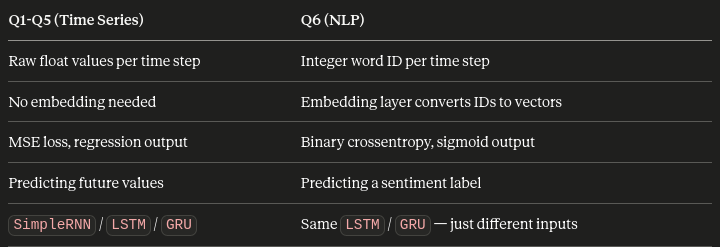

The RNN architecture is essentially identical — the only meaningful differences are how we prepare the input (embeddings instead of raw numbers) and how we interpret the output (a class label instead of a future value). That's the key takeaway from this question — RNNs are flexible enough to handle both.